
==================== CD-HIT 0.4 ====================
总特征数: 2400
分类标签分布:
0    667
1    291
Name: Label, dtype: int64
正在计算所有特征的F1值和判别方向系数...

F1值前10的特征（降序）- 含判别方向系数:
   feature  single_feature_f1  lr_coefficient
0  RR.gap2           0.570149        0.929881
1  WP.gap1           0.544803       -1.288920
2  RR.gap5           0.532725        0.739501
3  LW.gap4           0.527958       -0.788324
4  LN.gap2           0.521053       -0.669056
5  WL.gap4           0.520202       -0.713353
6  YW.gap1           0.510451       -0.809409
7  GF.gap3           0.502229        0.544398
8  FI.gap2           0.502216        0.611166
9  YW.gap5           0.495071       -0.797979
前10特征F1+判别系数结果已保存至: top10_features_f1_coef_cdhit_0.4.csv


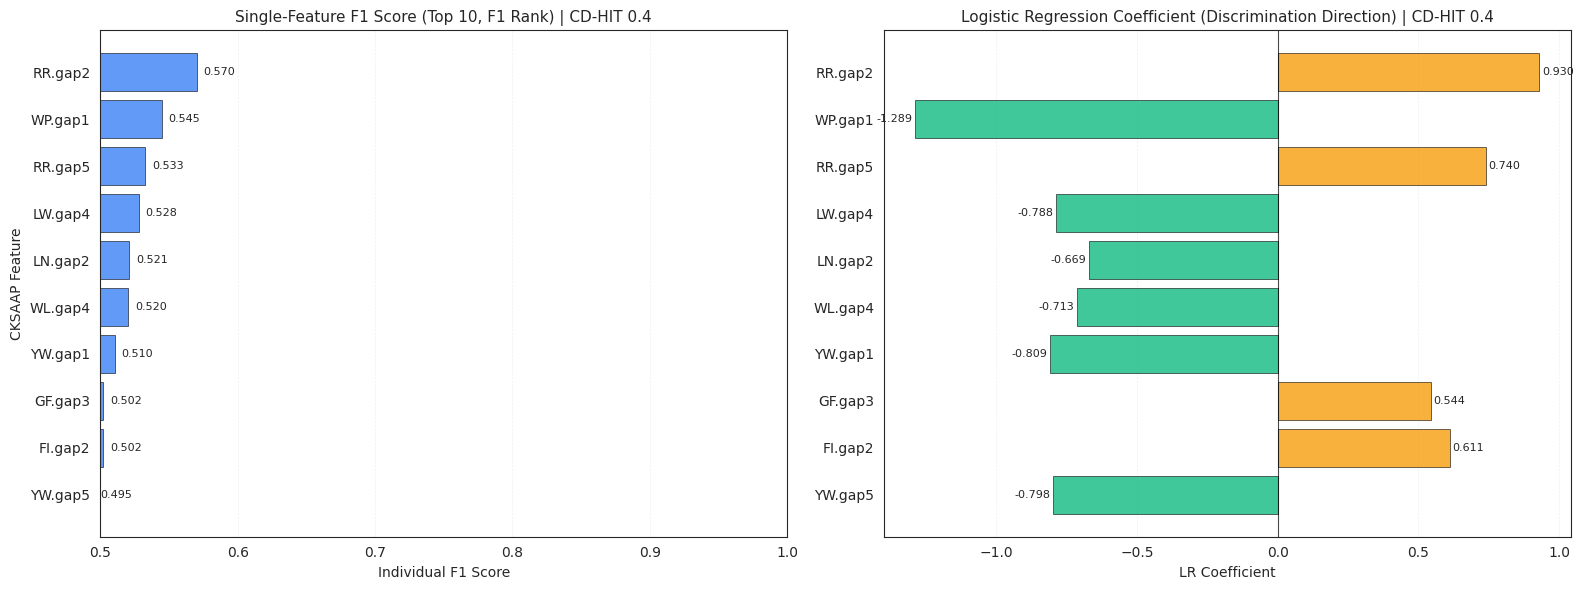


==================== CD-HIT 0.5 ====================
总特征数: 2400
分类标签分布:
0    1029
1     459
Name: Label, dtype: int64
正在计算所有特征的F1值和判别方向系数...

F1值前10的特征（降序）- 含判别方向系数:
   feature  single_feature_f1  lr_coefficient
0  RR.gap2           0.606936        1.044287
1  WP.gap1           0.562691       -1.397760
2  RR.gap5           0.552400        0.842898
3  LW.gap4           0.546994       -0.877933
4  YW.gap1           0.530292       -0.890855
5  LN.gap2           0.527027       -0.739044
6  WV.gap0           0.526641       -0.707415
7  GF.gap3           0.525424        0.636514
8  WL.gap4           0.520767       -0.732441
9  LY.gap3           0.518998       -0.338039
前10特征F1+判别系数结果已保存至: top10_features_f1_coef_cdhit_0.5.csv


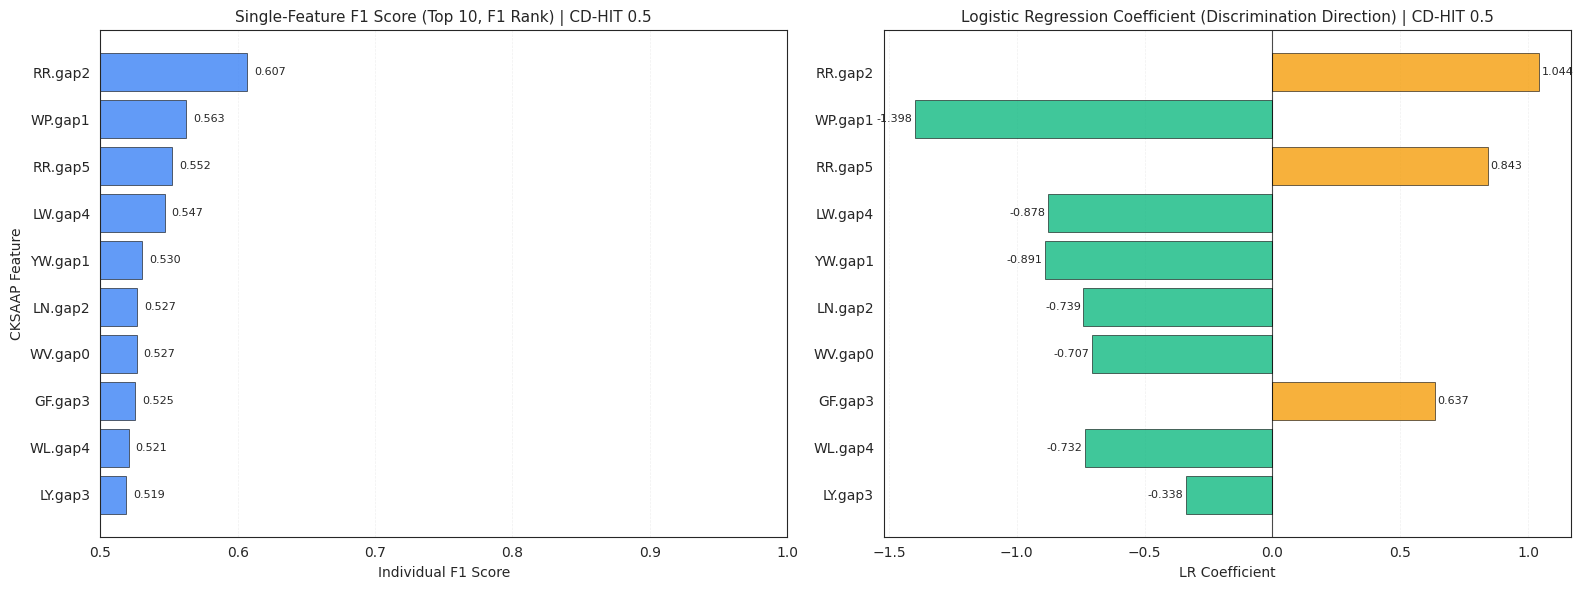


==================== CD-HIT 0.6 ====================
总特征数: 2400
分类标签分布:
0    1378
1     640
Name: Label, dtype: int64
正在计算所有特征的F1值和判别方向系数...

F1值前10的特征（降序）- 含判别方向系数:
   feature  single_feature_f1  lr_coefficient
0  RR.gap2           0.612500        1.027130
1  WP.gap1           0.568080       -1.302795
2  RR.gap5           0.557447        0.819378
3  LW.gap4           0.554807       -0.820252
4  YW.gap1           0.540230       -0.894376
5  WV.gap0           0.538724       -0.816443
6  LN.gap2           0.533578       -0.714307
7  WD.gap2           0.531579       -0.784424
8  LR.gap3           0.530313        0.585893
9  LY.gap3           0.522968       -0.373804
前10特征F1+判别系数结果已保存至: top10_features_f1_coef_cdhit_0.6.csv


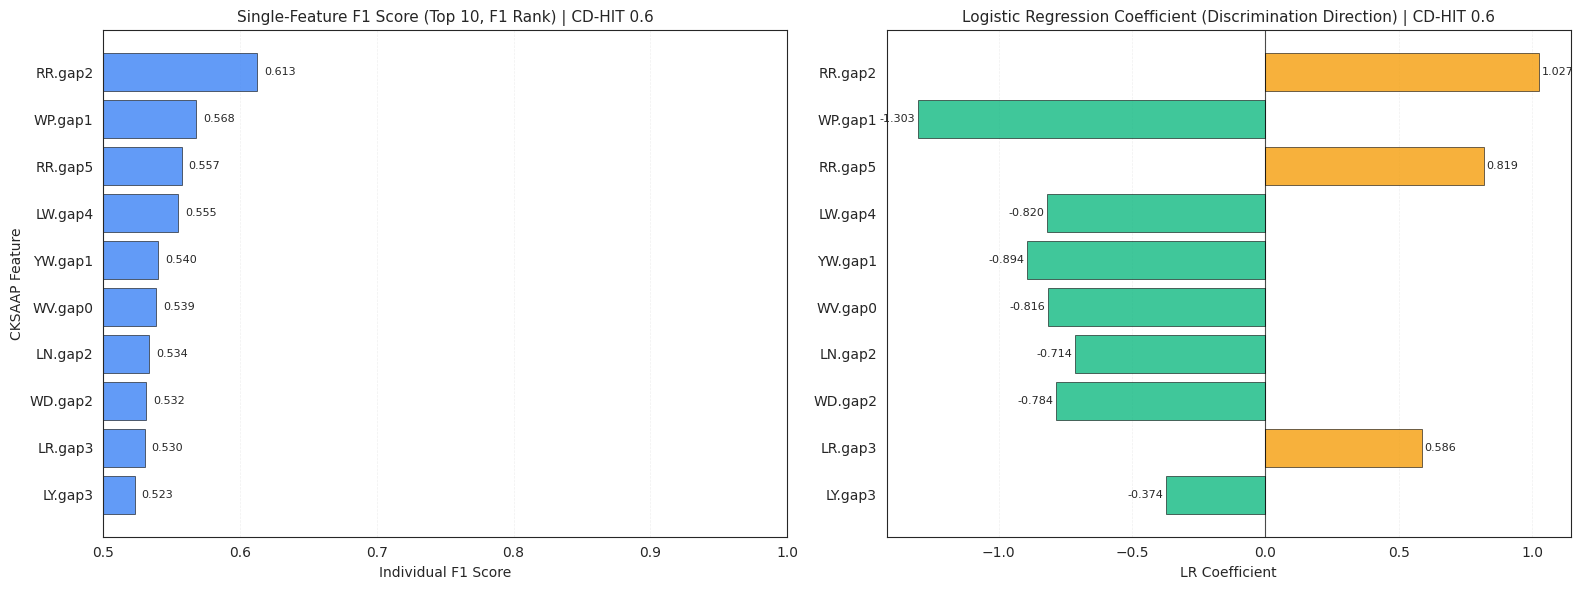


==================== CD-HIT 0.7 ====================
总特征数: 2400
分类标签分布:
0    1769
1     866
Name: Label, dtype: int64
正在计算所有特征的F1值和判别方向系数...

F1值前10的特征（降序）- 含判别方向系数:
   feature  single_feature_f1  lr_coefficient
0  RR.gap2           0.625261        1.068581
1  WP.gap1           0.582770       -1.226933
2  RR.gap5           0.580338        0.862147
3  LW.gap4           0.575242       -0.836319
4  WV.gap0           0.550411       -0.900009
5  WD.gap2           0.548687       -0.780480
6  YW.gap1           0.547675       -0.847331
7  LN.gap2           0.545872       -0.719621
8  LR.gap3           0.541024        0.608100
9  FE.gap2           0.531750        0.552232
前10特征F1+判别系数结果已保存至: top10_features_f1_coef_cdhit_0.7.csv


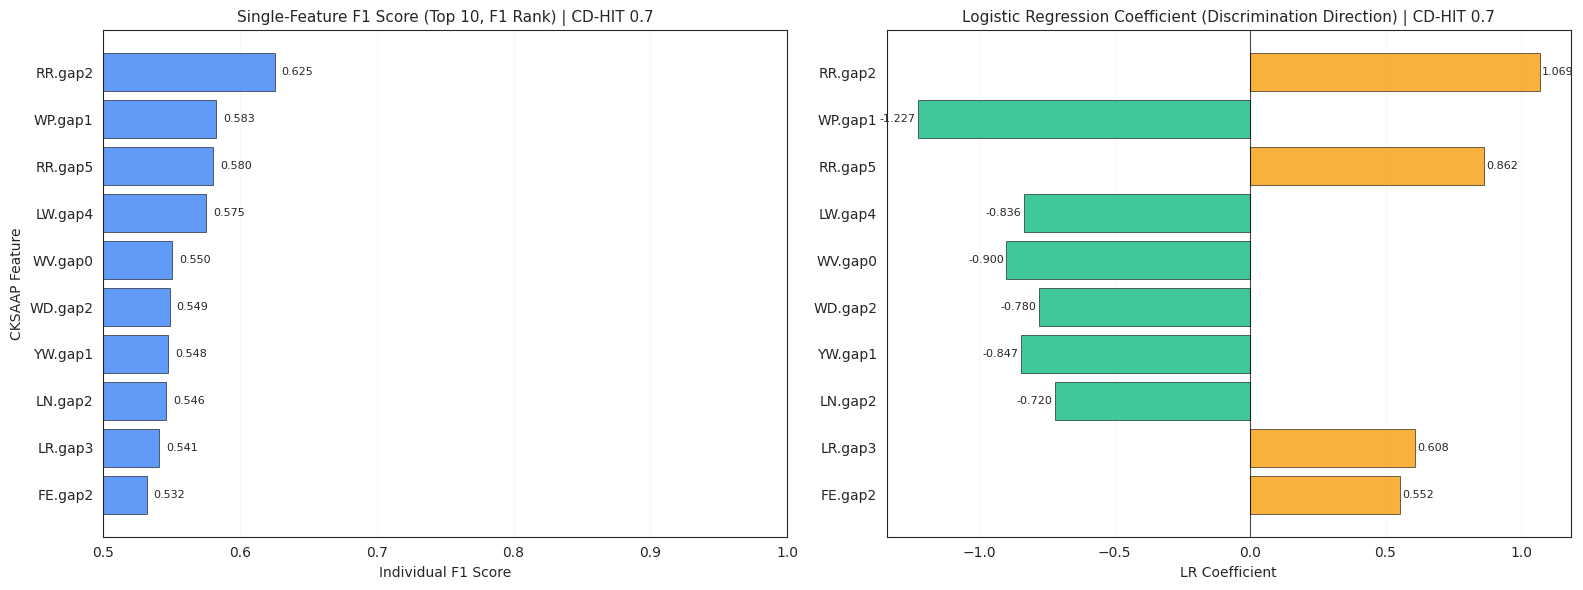


所有有效阈值的双生子图展示完成！


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

def calculate_f1_and_coef(df, feature_col, group_col='Label'):
    """
    同时计算单个特征的F1值（判别能力）和逻辑回归系数（判别方向）
    系数正负反映判别方向：
    - 正系数：特征值越高，越倾向于属于VGICs（1类，VGICs富集）
    - 负系数：特征值越高，越倾向于属于non-VGICs（0类，VGICs缺失）
    """
    # 准备特征和标签
    X = df[[feature_col]].values
    y = df[group_col].values
    
    # 特征标准化（保证系数可对比，与F1计算逻辑一致）
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 训练逻辑回归分类器
    clf = LogisticRegression(random_state=42, class_weight='balanced')
    clf.fit(X_scaled, y)
    
    # 计算F1值
    y_pred = clf.predict(X_scaled)
    f1 = f1_score(y, y_pred, pos_label=1, average='binary')
    
    # 获取逻辑回归系数（单特征仅1个系数，反映判别方向和强度）
    coef = clf.coef_[0][0]
    
    return {
        'feature': feature_col,
        'single_feature_f1': f1,
        'lr_coefficient': coef  # 判别方向系数
    }

def plot_f1_and_coef_two_subplots(top10_df, cd_hit_threshold):
    """
    两个有价值的子图（1行2列，无冗余，信息互补）：
    左=F1值水平柱状图（展示判别能力，按F1降序）
    右=逻辑回归系数水平柱状图（展示判别方向，与左图特征一一对应）
    """
    # 配置布局：1行2列，两个子图，尺寸适配展示
    fig, (ax_f1, ax_coef) = plt.subplots(1, 2, figsize=(16, 6))
    # 白色背景，解决样式报错
    fig.patch.set_facecolor('white')
    
    # 提取按F1降序排列的核心数据
    features = top10_df['feature'].values
    f1_scores = top10_df['single_feature_f1'].values
    lr_coefs = top10_df['lr_coefficient'].values
    y_pos = np.arange(len(features))  # y轴位置索引

    # 定义颜色（贴合你的研究场景，色盲友好，信息直观）
    color_f1 = '#3B82F6'  # F1柱状图统一颜色（突出判别能力）
    color_coef_pos = '#F59E0B'  # 正系数（VGICs富集，暖色调）
    color_coef_neg = '#10B981'  # 负系数（VGICs缺失，冷色调）

    # -------------------- 左侧子图：F1值柱状图（核心，展示判别能力） --------------------
    # 绘制水平柱状图
    f1_bars = ax_f1.barh(y_pos, f1_scores, color=color_f1, alpha=0.8, edgecolor='black', linewidth=0.5)
    # 反转y轴，F1最高特征在顶部
    ax_f1.invert_yaxis()
    # 设置y轴标签（特征名）
    ax_f1.set_yticks(y_pos)
    ax_f1.set_yticklabels(features)
    # 设置标题和坐标轴标签（默认样式，无复杂格式）
    ax_f1.set_title(f'Single-Feature F1 Score (Top 10, F1 Rank) | CD-HIT {cd_hit_threshold}', fontsize=11)
    ax_f1.set_xlabel('Individual F1 Score', fontsize=10)
    ax_f1.set_ylabel('CKSAAP Feature', fontsize=10)
    # 设置x轴范围，便于对比
    ax_f1.set_xlim(0.5, 1.0)
    # 标注F1数值
    for bar, f1 in zip(f1_bars, f1_scores):
        ax_f1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{f1:.3f}', ha='left', va='center', fontsize=8)
    # 添加轻微网格
    ax_f1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)

    # -------------------- 右侧子图：逻辑回归系数柱状图（补充判别方向，无冗余） --------------------
    # 根据系数正负分配颜色
    coef_colors = [color_coef_pos if c > 0 else color_coef_neg for c in lr_coefs]
    # 绘制水平柱状图
    coef_bars = ax_coef.barh(y_pos, lr_coefs, color=coef_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    # 反转y轴，与左侧F1图特征顺序完全一致
    ax_coef.invert_yaxis()
    # 设置y轴标签（与左侧一致，保持对应关系）
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels(features)
    # 设置标题和坐标轴标签
    ax_coef.set_title(f'Logistic Regression Coefficient (Discrimination Direction) | CD-HIT {cd_hit_threshold}', fontsize=11)
    ax_coef.set_xlabel('LR Coefficient', fontsize=10)
    # 添加垂直零值线，清晰区分正负系数（判别方向）
    ax_coef.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.7)
    # 标注系数数值
    for bar, coef in zip(coef_bars, lr_coefs):
        text_x = bar.get_width() + 0.01 if coef > 0 else bar.get_width() - 0.01
        ha = 'left' if coef > 0 else 'right'
        ax_coef.text(text_x, bar.get_y() + bar.get_height()/2,
                     f'{coef:.3f}', ha=ha, va='center', fontsize=8)
    # 添加轻微网格
    ax_coef.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)

    # -------------------- 全局布局调整 --------------------
    plt.subplots_adjust(wspace=0.3)  # 调整两个子图的水平间距
    plt.tight_layout()
    # 仅展示图片，不保存
    plt.show()

# 主程序
if __name__ == "__main__":
    # 遍历每个CD-HIT阈值文件
    cd_hit_thresholds = [0.4, 0.5, 0.6, 0.7]
    for threshold in cd_hit_thresholds:
        # 1. 读取数据
        input_file = f"./encoded_cksaap_{threshold}_with_label.csv"
        try:
            df = pd.read_csv(input_file)
        except FileNotFoundError:
            print(f"警告：文件 {input_file} 未找到，跳过该阈值！")
            continue
        
        # 2. 验证分类列有效性
        groups = df['Label'].unique()
        if set(groups) != {0, 1}:
            print(f"警告：CD-HIT {threshold} 的class列不是0/1二分类，跳过该阈值！")
            continue
        
        # 3. 筛选所有特征列
        feature_cols = [col for col in df.columns if col != 'Label']
        print(f"\n==================== CD-HIT {threshold} ====================")
        print(f"总特征数: {len(feature_cols)}")
        print(f"分类标签分布:")
        print(df["Label"].value_counts())
        
        # 4. 计算所有特征的F1值和判别方向系数
        feature_metrics_list = []
        print(f"正在计算所有特征的F1值和判别方向系数...")
        for feature in feature_cols:
            metrics_dict = calculate_f1_and_coef(df, feature)
            feature_metrics_list.append(metrics_dict)
        
        # 5. 按F1降序排序，取前10
        metrics_df = pd.DataFrame(feature_metrics_list)
        metrics_df_sorted = metrics_df.sort_values(by='single_feature_f1', ascending=False)
        top10_metrics_df = metrics_df_sorted.head(10).reset_index(drop=True)
        
        # 6. 打印前10特征的核心指标
        print(f"\nF1值前10的特征（降序）- 含判别方向系数:")
        print(top10_metrics_df[['feature', 'single_feature_f1', 'lr_coefficient']])
        
        # 7. 保存前10特征指标结果（可选）
        top10_output_file = f"top10_features_f1_coef_cdhit_{threshold}.csv"
        top10_metrics_df.to_csv(top10_output_file, index=False)
        print(f"前10特征F1+判别系数结果已保存至: {top10_output_file}")
        
        # 8. 绘制两个有价值的子图（F1 + 判别方向系数）
        plot_f1_and_coef_two_subplots(top10_metrics_df, threshold)
    
    print(f"\n所有有效阈值的双生子图展示完成！")

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from joblib import Parallel, delayed
import os
import warnings
# 新增：导入层次聚类相关模块
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# 忽略并行计算中可能出现的线性收敛警告，保持输出整洁
warnings.filterwarnings('ignore')

# ================= 配置区域 =================
SAVE_DIR = "./feature_analysis_results/"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# 并行核心数设置：-1 表示使用所有核心，-2 表示保留一个核心不需用
# 既然你有64核，建议设置为 -1 或 60
N_JOBS = -1 

# ================= 核心计算函数 (微调以适应并行) =================

def process_single_feature(feature_name, X_col, y, total_samples):
    """
    计算单个特征指标的原子函数。
    注意：这里传入的是 numpy array (X_col)，而不是整个 df，以减少内存传输开销。
    """
    # 转换为 2D 数组 (n_samples, 1)
    X = X_col.reshape(-1, 1)
    
    # 检查方差，若是常量特征直接返回0
    if np.var(X) == 0:
        return {
            'feature': feature_name,
            'single_feature_f1': 0.0,
            'lr_coefficient': 0.0
        }

    # 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 训练逻辑回归 (使用 liblinear 求解器对于小维数据通常更快)
    # n_jobs=1 确保单个任务只用一个核，避免与外层并行冲突
    clf = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear', n_jobs=1)
    clf.fit(X_scaled, y)
    
    # 计算 F1
    y_pred = clf.predict(X_scaled)
    f1 = f1_score(y, y_pred, pos_label=1, average='binary')
    
    # 获取系数
    coef = clf.coef_[0][0]
    
    return {
        'feature': feature_name,
        'single_feature_f1': f1,
        'lr_coefficient': coef
    }

# ================= 绘图函数 (核心修改：热图聚类排序) =================

def plot_analysis_results(top10_df, full_df, cd_hit_threshold):
    """绘制组合图：F1能力 + 系数方向 + 相关性热图（带聚类排序）"""
    fig = plt.figure(figsize=(20, 6), constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

    ax_f1 = fig.add_subplot(gs[0, 0])
    ax_coef = fig.add_subplot(gs[0, 1])
    ax_corr = fig.add_subplot(gs[0, 2])

    features = top10_df['feature'].values
    f1_scores = top10_df['single_feature_f1'].values
    lr_coefs = top10_df['lr_coefficient'].values
    y_pos = np.arange(len(features))

    # 图1：F1 Score
    ax_f1.barh(y_pos, f1_scores, color='#4F46E5', alpha=0.8)
    ax_f1.invert_yaxis()
    ax_f1.set_yticks(y_pos)
    ax_f1.set_yticklabels(features, fontsize=10)
    ax_f1.set_title(f'Discriminative Power (F1 Score)\nCD-HIT {cd_hit_threshold}', fontweight='bold')
    ax_f1.set_xlabel('F1 Score')
    ax_f1.set_xlim(min(f1_scores)*0.9, 1.0) # 动态调整范围
    ax_f1.grid(axis='x', linestyle='--', alpha=0.5)
    for i, v in enumerate(f1_scores):
        ax_f1.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

    # 图2：Direction
    colors = ['#EF4444' if x > 0 else '#3B82F6' for x in lr_coefs]
    ax_coef.barh(y_pos, lr_coefs, color=colors, alpha=0.8)
    ax_coef.invert_yaxis()
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels([]) 
    ax_coef.set_title(f'Discriminative Direction (Coefficient)\nCD-HIT {cd_hit_threshold}', fontweight='bold')
    ax_coef.set_xlabel('Coefficient Value')
    ax_coef.axvline(0, color='black', linewidth=1)
    ax_coef.grid(axis='x', linestyle='--', alpha=0.5)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#EF4444', label='Enriched in VGICs (Pos)'),
        Patch(facecolor='#3B82F6', label='Enriched in Non-VGICs (Neg)')
    ]
    ax_coef.legend(handles=legend_elements, loc='lower right', fontsize=9)

    # 图3：Correlation Heatmap (核心修改：层次聚类排序)
    top_feature_data = full_df[features]
    corr_matrix = top_feature_data.corr()
    
    # 步骤1：将相关性矩阵转换为距离矩阵（1 - 绝对相关性，保证距离非负）
    distance_matrix = 1 - np.abs(corr_matrix)
    # 步骤2：层次聚类（ward法：最小化类内方差，适合连续数据）
    linkage_matrix = linkage(squareform(distance_matrix), method='ward')
    # 步骤3：获取聚类后的叶子节点顺序（即排序后的特征索引）
    sorted_idx = leaves_list(linkage_matrix)
    # 步骤4：根据聚类结果重新排列相关性矩阵的行和列
    corr_matrix_sorted = corr_matrix.iloc[sorted_idx, sorted_idx]
    # 步骤5：获取排序后的特征名
    sorted_features = [features[i] for i in sorted_idx]

    # 绘制排序后的热图
    sns.heatmap(corr_matrix_sorted, ax=ax_corr, cmap='coolwarm', vmin=-1, vmax=1, 
                annot=True, fmt=".2f", annot_kws={"size": 8},
                square=True, cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
    ax_corr.set_title(f'Redundancy Analysis (Top 10, Clustered)\nCD-HIT {cd_hit_threshold}', fontweight='bold')
    # ax_corr.set_xticklabels(sorted_features, rotation=45, ha='right', fontsize=9)
    # ax_corr.set_yticklabels(sorted_features, rotation=0, fontsize=9)

    save_path = os.path.join(SAVE_DIR, f"Analysis_CDHIT_{cd_hit_threshold}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"  -> 图片已保存: {save_path}")
    plt.close()

# ================= 主程序 =================
if __name__ == "__main__":
    print(f"检测到系统配置，将使用 {N_JOBS} 个CPU核心进行并行计算。")
    
    cd_hit_thresholds = [0.4, 0.5, 0.6, 0.7]
    
    for threshold in cd_hit_thresholds:
        input_file = f"./new/encoded_cksaap_{threshold}_with_label.csv"
        
        if not os.path.exists(input_file):
            print(f"跳过：文件不存在 {input_file}")
            continue
            
        print(f"\nProcessing CD-HIT {threshold} ...")
        df = pd.read_csv(input_file)
        
        # 准备数据
        # 提取 y 一次
        y = df['Label'].values
        total_samples = len(y)
        
        # 提取所有特征列名
        feature_cols = [col for col in df.columns if col != 'Label']
        
        # 【核心并行部分】
        # 使用 joblib.Parallel 分发任务
        # delayed() 包装函数调用
        # 注意：这里我们传入 df[col].values，这样每个进程只拿到那一列的数据，
        # 而不是把整个巨大的 df 复制 64 份传进去，这会节省大量内存和IO时间。
        print(f"  -> 启动并行计算 ({len(feature_cols)} 个特征)...")
        
        feature_metrics_list = Parallel(n_jobs=N_JOBS)(
            delayed(process_single_feature)(
                col, 
                df[col].values, 
                y, 
                total_samples
            ) for col in tqdm(feature_cols, desc="Parallel Progress")
        )
        
        # 后处理和绘图逻辑保持不变
        metrics_df = pd.DataFrame(feature_metrics_list)
        metrics_df_sorted = metrics_df.sort_values(by='single_feature_f1', ascending=False)
        top10_metrics_df = metrics_df_sorted.head(30).reset_index(drop=True)
        
        csv_save_path = os.path.join(SAVE_DIR, f"Top30_Metrics_CDHIT_{threshold}.csv")
        top10_metrics_df.to_csv(csv_save_path, index=False)
        
        plot_analysis_results(top10_metrics_df, df, threshold)

    print(f"\n所有任务完成！结果保存在: {SAVE_DIR}")

检测到系统配置，将使用 -1 个CPU核心进行并行计算。

Processing CD-HIT 0.4 ...
  -> 启动并行计算 (2400 个特征)...


Parallel Progress: 100%|██████████| 2400/2400 [00:01<00:00, 1235.99it/s]


  -> 图片已保存: ./feature_analysis_results/Analysis_CDHIT_0.4.png

Processing CD-HIT 0.5 ...
  -> 启动并行计算 (2400 个特征)...


Parallel Progress: 100%|██████████| 2400/2400 [00:02<00:00, 813.74it/s]


  -> 图片已保存: ./feature_analysis_results/Analysis_CDHIT_0.5.png

Processing CD-HIT 0.6 ...
  -> 启动并行计算 (2400 个特征)...


Parallel Progress: 100%|██████████| 2400/2400 [00:03<00:00, 779.10it/s]


  -> 图片已保存: ./feature_analysis_results/Analysis_CDHIT_0.6.png

Processing CD-HIT 0.7 ...
  -> 启动并行计算 (2400 个特征)...


Parallel Progress: 100%|██████████| 2400/2400 [00:01<00:00, 1389.95it/s]


  -> 图片已保存: ./feature_analysis_results/Analysis_CDHIT_0.7.png

所有任务完成！结果保存在: ./feature_analysis_results/


矩阵形式的折线图数据已保存至: Feature_Rank_Matrix.csv


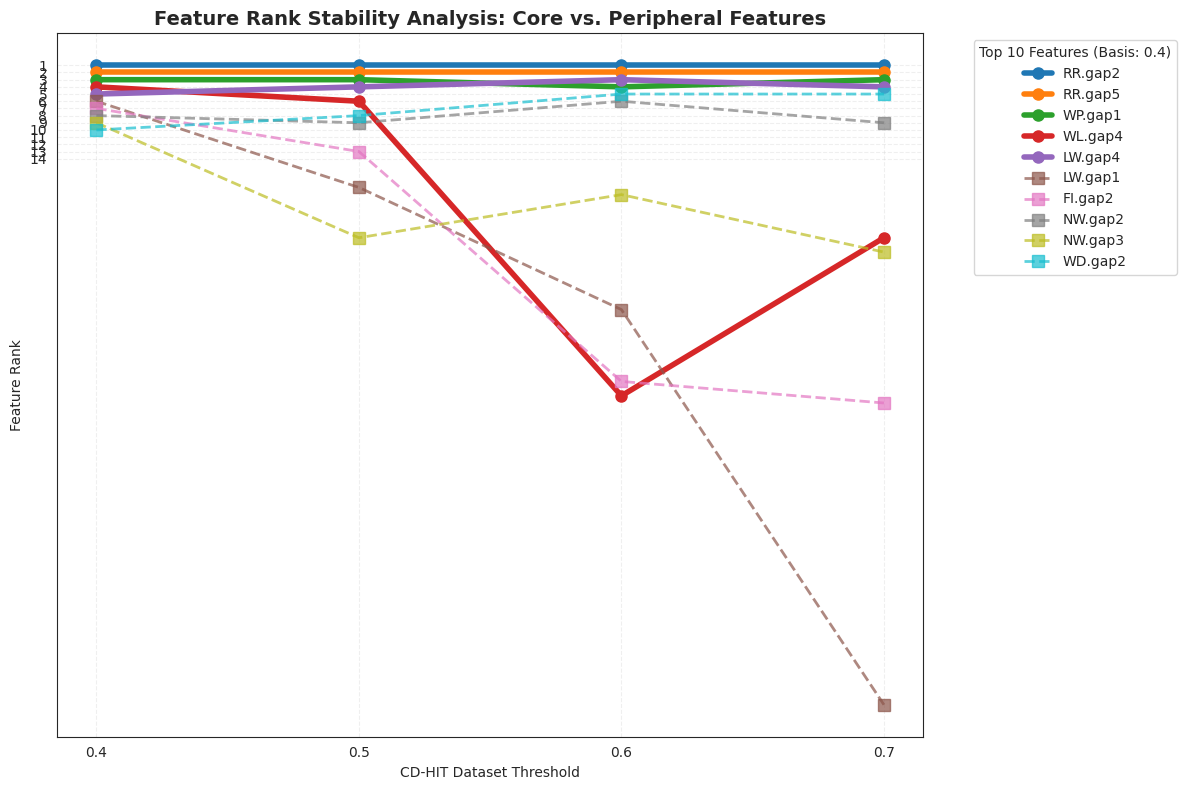

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ================= 配置 =================
RESULT_DIR = "./single_feature_robustness/"
THRESHOLDS = [0.4, 0.5, 0.6, 0.7]

# ================= 数据读取与整理 =================
all_data = []

for t in THRESHOLDS:
    fname = os.path.join(RESULT_DIR, f"Feature_Ranking_MultiModel_CDHIT_{t}.csv")
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        # 增加排名列
        df['Rank'] = range(1, len(df) + 1)
        df['Threshold'] = str(t)
        all_data.append(df)

if not all_data:
    print("未找到数据，请先运行上一步的特征评估代码！")
else:
    full_df = pd.concat(all_data)
    
    # 1. 确定要展示的特征：以 CD-HIT 0.4 的 Top 10 为基准
    ref_df = full_df[full_df['Threshold'] == '0.4'].sort_values('Rank').head(10)
    top_features = ref_df['feature'].values
    
    # 筛选出这些特征在所有数据集中的数据（绘图核心数据）
    plot_df = full_df[full_df['feature'].isin(top_features)].copy()

    # ================= 整理为矩阵形式并保存 =================
    # 只保留核心列：特征、阈值、排名
    core_data = plot_df[['feature', 'Threshold', 'Rank']].copy()
    
    # 透视成矩阵：行=特征，列=阈值，值=排名
    rank_matrix = core_data.pivot(
        index='feature',       # 行：特征名称
        columns='Threshold',   # 列：CD-HIT阈值
        values='Rank'          # 值：特征排名
    )
    
    # 确保列的顺序与THRESHOLDS一致（0.4→0.5→0.6→0.7）
    rank_matrix = rank_matrix.reindex(columns=[str(t) for t in THRESHOLDS])
    
    # 确保行的顺序是0.4阈值下的Top10顺序（保持和折线图一致）
    rank_matrix = rank_matrix.reindex(index=top_features)
    
    # 保存矩阵形式的CSV
    matrix_csv_path = "Feature_Rank_Matrix.csv"
    rank_matrix.to_csv(matrix_csv_path, encoding='utf-8-sig')
    print(f"矩阵形式的折线图数据已保存至: {matrix_csv_path}")

    # ================= 图表绘制（保持不变） =================
    plt.figure(figsize=(12, 8))
    colors = sns.color_palette("tab10", n_colors=10)
    
    for i, feature in enumerate(top_features):
        subset = plot_df[plot_df['feature'] == feature]
        subset = subset.sort_values('Threshold')
        
        if i < 5:
            lw = 4
            ls = '-'
            alpha = 1.0
            marker = 'o'
        else:
            lw = 2
            ls = '--'
            alpha = 0.7
            marker = 's'
            
        plt.plot(subset['Threshold'], subset['Rank'], label=feature, 
                 color=colors[i], linewidth=lw, linestyle=ls, marker=marker, markersize=8, alpha=alpha)

    plt.gca().invert_yaxis()
    plt.yticks(range(1, 15))
    plt.xlabel('CD-HIT Dataset Threshold')
    plt.ylabel('Feature Rank')
    plt.title('Feature Rank Stability Analysis: Core vs. Peripheral Features', fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Top 10 Features (Basis: 0.4)')
    plt.tight_layout()
    plt.savefig("Rank_Tracking_BumpChart.png", dpi=300)
    plt.show()